<a href="https://colab.research.google.com/github/Muhammad-Waleed-Source/Machine-Learning/blob/main/Day-61/Polynomial-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [2]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# y = 0.8x^2 + 0.9x + 2

In [3]:
X

array([[-2.24723586],
       [-2.63862194],
       [-0.03739665],
       [ 1.96273586],
       [-0.03048618],
       [ 2.63464351],
       [ 0.22806069],
       [ 1.63626383],
       [ 2.17439964],
       [-0.58424116],
       [-1.51175306],
       [-2.98280752],
       [ 0.90094255],
       [ 2.22145021],
       [ 1.48585905],
       [-0.63133084],
       [ 0.63300113],
       [-1.47216586],
       [ 2.16141016],
       [-2.29299302],
       [-0.81167539],
       [ 0.86331399],
       [ 1.12565672],
       [ 0.48353355],
       [ 1.11447079],
       [-1.78414033],
       [ 0.20026262],
       [ 1.40720757],
       [-2.33596884],
       [ 1.76055427],
       [ 1.99479382],
       [-0.13044958],
       [-2.38517748],
       [-2.58071736],
       [ 2.02535662],
       [ 1.87821827],
       [-0.52823493],
       [ 2.20491175],
       [-2.83466928],
       [-0.66033665],
       [ 0.65304276],
       [ 1.02019751],
       [ 1.52953245],
       [ 1.87428976],
       [ 1.20853092],
       [ 2

Text(0, 0.5, 'y')

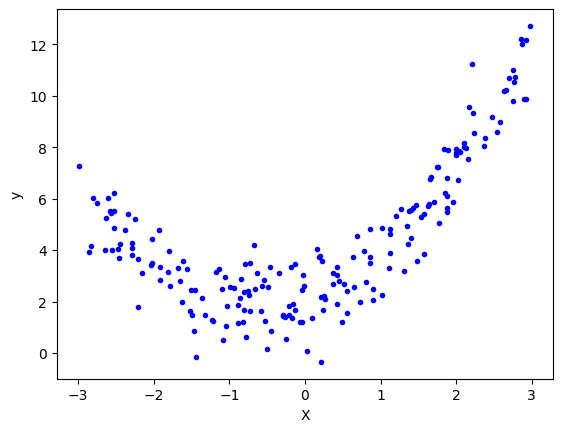

In [4]:
plt.plot(X, y, 'b.')
plt.xlabel("X")
plt.ylabel("y")

## Train test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [6]:
X_train

array([[ 2.76720966],
       [-0.93634521],
       [ 2.77420212],
       [-0.88901951],
       [-2.46604109],
       [-1.62794575],
       [ 1.02019751],
       [-2.28207657],
       [ 1.39905685],
       [ 2.63464351],
       [ 1.65498916],
       [ 2.86636413],
       [-2.98280752],
       [-0.03583743],
       [ 1.11447079],
       [-2.60741675],
       [-0.98651819],
       [ 2.17439964],
       [ 1.8940222 ],
       [-0.16831471],
       [-2.33596884],
       [ 2.09823437],
       [-2.55537979],
       [ 1.52953245],
       [ 2.13266842],
       [-1.05130987],
       [-1.23391118],
       [ 1.99100029],
       [-0.18763029],
       [ 2.46721986],
       [-0.86497762],
       [-2.03679987],
       [ 1.87606572],
       [-0.88830779],
       [-2.63862194],
       [-2.02721015],
       [ 1.87597905],
       [-2.80271355],
       [ 1.84500127],
       [ 0.08813991],
       [ 2.69297518],
       [-0.52823493],
       [-2.02493014],
       [-0.85135132],
       [-2.53151703],
       [-2

## Simple Linear Regression Model

In [7]:
lr = LinearRegression()

In [8]:
lr.fit(X_train, y_train)

LinearRegression()

In [9]:
y_pred = lr.predict(X_test)

In [10]:
r2_score(y_test, y_pred)

0.4096416752407017

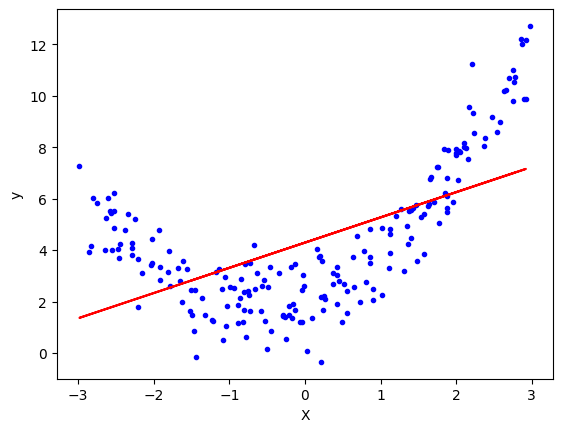

In [11]:
plt.plot(X, y, 'b.')
plt.plot(X_train, lr.predict(X_train), color='r')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

## Applying Polynomial Linear Regression

In [31]:
poly = PolynomialFeatures(degree=2)

In [32]:
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [33]:
print(X_train[0])
print(X_train_trans[0])

# We can see that we have now 3 cols instead of 1

[2.76720966]
[1.         2.76720966 7.65744928]


## Training model again

In [34]:
lr = LinearRegression()

In [35]:
lr.fit(X_train_trans, y_train)

LinearRegression()

In [36]:
y_pred = lr.predict(X_test_trans)

In [37]:
r2_score(y_test, y_pred)

0.8698001529703242

In [38]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.97080785 0.78430705]]
[2.17489702]


In [29]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

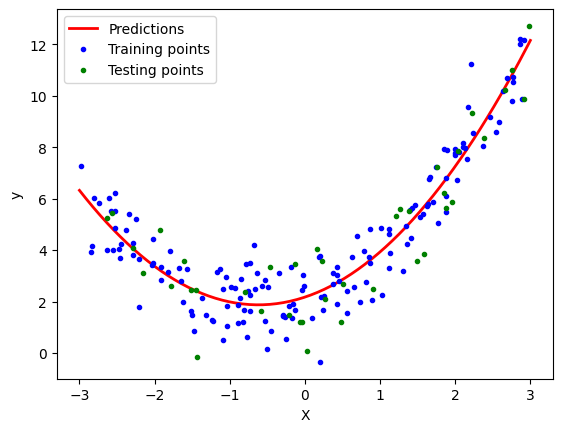

In [30]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [44]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

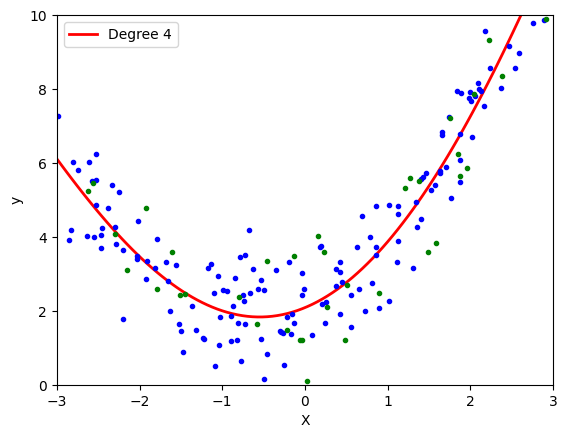

In [46]:
polynomial_regression(4)

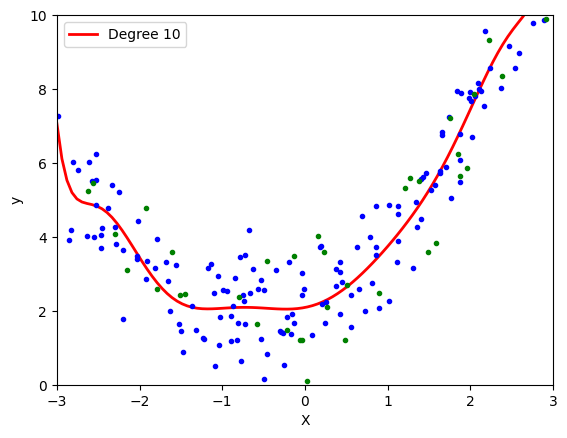

In [48]:
polynomial_regression(10)

# We can see that our model now relies on training data alot

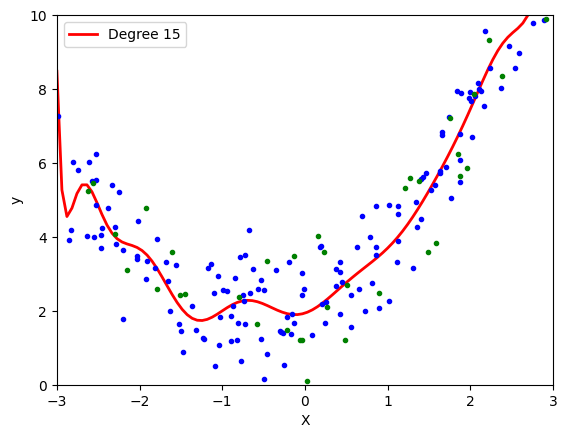

In [49]:
polynomial_regression(15)

## 3D polynomial regression

In [51]:
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [54]:
import plotly.express as px

fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [55]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

LinearRegression()

In [56]:
x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [58]:
import plotly.graph_objects as go

fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [59]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [70]:
poly = PolynomialFeatures(degree=30)
X_multi_trans = poly.fit_transform(X_multi)

In [71]:
print("Input",poly.n_features_in_)
print("Ouput",poly.n_output_features_)
print("Powers\n",poly.powers_)

Input 2
Ouput 496
Powers
 [[ 0  0]
 [ 1  0]
 [ 0  1]
 [ 2  0]
 [ 1  1]
 [ 0  2]
 [ 3  0]
 [ 2  1]
 [ 1  2]
 [ 0  3]
 [ 4  0]
 [ 3  1]
 [ 2  2]
 [ 1  3]
 [ 0  4]
 [ 5  0]
 [ 4  1]
 [ 3  2]
 [ 2  3]
 [ 1  4]
 [ 0  5]
 [ 6  0]
 [ 5  1]
 [ 4  2]
 [ 3  3]
 [ 2  4]
 [ 1  5]
 [ 0  6]
 [ 7  0]
 [ 6  1]
 [ 5  2]
 [ 4  3]
 [ 3  4]
 [ 2  5]
 [ 1  6]
 [ 0  7]
 [ 8  0]
 [ 7  1]
 [ 6  2]
 [ 5  3]
 [ 4  4]
 [ 3  5]
 [ 2  6]
 [ 1  7]
 [ 0  8]
 [ 9  0]
 [ 8  1]
 [ 7  2]
 [ 6  3]
 [ 5  4]
 [ 4  5]
 [ 3  6]
 [ 2  7]
 [ 1  8]
 [ 0  9]
 [10  0]
 [ 9  1]
 [ 8  2]
 [ 7  3]
 [ 6  4]
 [ 5  5]
 [ 4  6]
 [ 3  7]
 [ 2  8]
 [ 1  9]
 [ 0 10]
 [11  0]
 [10  1]
 [ 9  2]
 [ 8  3]
 [ 7  4]
 [ 6  5]
 [ 5  6]
 [ 4  7]
 [ 3  8]
 [ 2  9]
 [ 1 10]
 [ 0 11]
 [12  0]
 [11  1]
 [10  2]
 [ 9  3]
 [ 8  4]
 [ 7  5]
 [ 6  6]
 [ 5  7]
 [ 4  8]
 [ 3  9]
 [ 2 10]
 [ 1 11]
 [ 0 12]
 [13  0]
 [12  1]
 [11  2]
 [10  3]
 [ 9  4]
 [ 8  5]
 [ 7  6]
 [ 6  7]
 [ 5  8]
 [ 4  9]
 [ 3 10]
 [ 2 11]
 [ 1 12]
 [ 0 13]
 [14  0]
 [13  1]
 [12  2]
 [

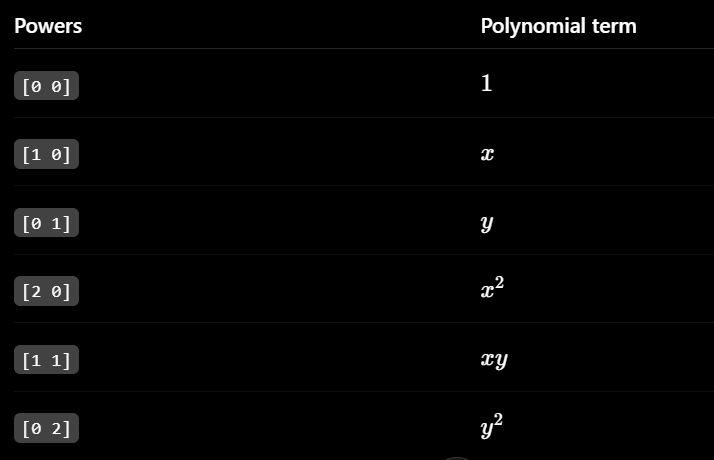

In [72]:
X_multi_trans.shape

(100, 496)

In [73]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

LinearRegression()

In [74]:
X_test_multi = poly.transform(final)

In [75]:
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [76]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()